In [1]:
%matplotlib inline
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import set_config
from tempfile import TemporaryDirectory
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from scipy.stats import chi2_contingency
import scipy.stats as ss
import seaborn as sns
import numpy as np
import warnings

In [2]:
ss = pd.read_csv("../data/sample_submission.csv")
target_column = ss.columns[-1]
target_column

'addicted_label'

In [3]:
df = pd.read_csv("../data/train.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  str    
 11  stress_level             636221 non-null  str    
 12  academic_work_impact     647145 non-null  str    
 13  addicted_label           691369 non-null  int64  
dtypes: float64(9), 

In [4]:
df.head()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


Check skewness

In [5]:
df.skew(numeric_only=True)

id                         9.539006e-17
age                       -3.680113e-02
daily_screen_time_hours   -1.319721e-01
social_media_hours         4.680814e-01
gaming_hours               5.447396e-01
work_study_hours           5.634571e-01
sleep_hours               -6.586670e-03
notifications_per_day     -2.065351e-01
app_opens_per_day         -1.264632e-01
weekend_screen_time       -6.340829e-02
addicted_label            -9.225193e-01
dtype: float64

Show missing counts

In [6]:
df.isna().sum().sort_values(ascending=False)

social_media_hours         133995
gaming_hours               126821
weekend_screen_time        112063
daily_screen_time_hours     95854
app_opens_per_day           80710
notifications_per_day       67584
stress_level                55148
work_study_hours            51518
sleep_hours                 44480
academic_work_impact        44224
gender                      29034
age                         28929
id                              0
addicted_label                  0
dtype: int64

Show missing percentage

In [7]:
df.isna().sum().sort_values(ascending=False)/len(df)*100

social_media_hours         19.381112
gaming_hours               18.343461
weekend_screen_time        16.208855
daily_screen_time_hours    13.864376
app_opens_per_day          11.673940
notifications_per_day       9.775388
stress_level                7.976638
work_study_hours            7.451592
sleep_hours                 6.433612
academic_work_impact        6.396584
gender                      4.199494
age                         4.184307
id                          0.000000
addicted_label              0.000000
dtype: float64

In [8]:
def show_missing_values(data, palette="viridis"):
    missing_values = data.isna().sum().sort_values(ascending=False)
    sns.barplot(x=missing_values.values, y=missing_values.index,palette=palette)

Show missing graph

C:\Users\abhin\AppData\Local\Temp\ipykernel_10260\737228090.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_values.values, y=missing_values.index,palette=palette)


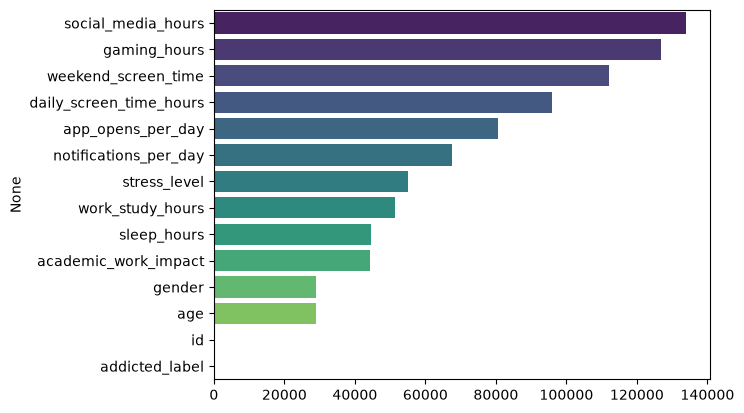

In [9]:
show_missing_values(df)

Check target counts

<Axes: xlabel='addicted_label', ylabel='count'>

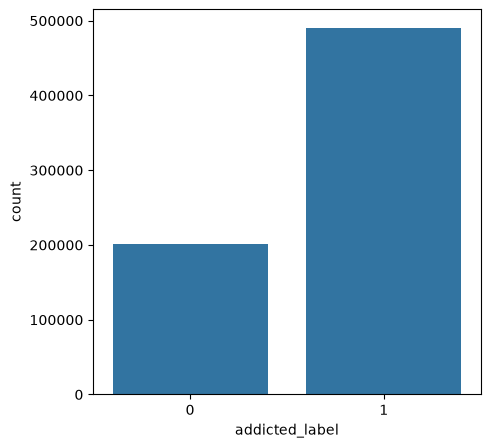

In [10]:
fig,axs = plt.subplots(figsize=(5,5),ncols=1)

sns.countplot(df,x=target_column,ax=axs)

Check categorical target correlations

In [6]:
cat_cols = df.select_dtypes(include="str").columns
cat_cols

Index(['gender', 'stress_level', 'academic_work_impact'], dtype='str')

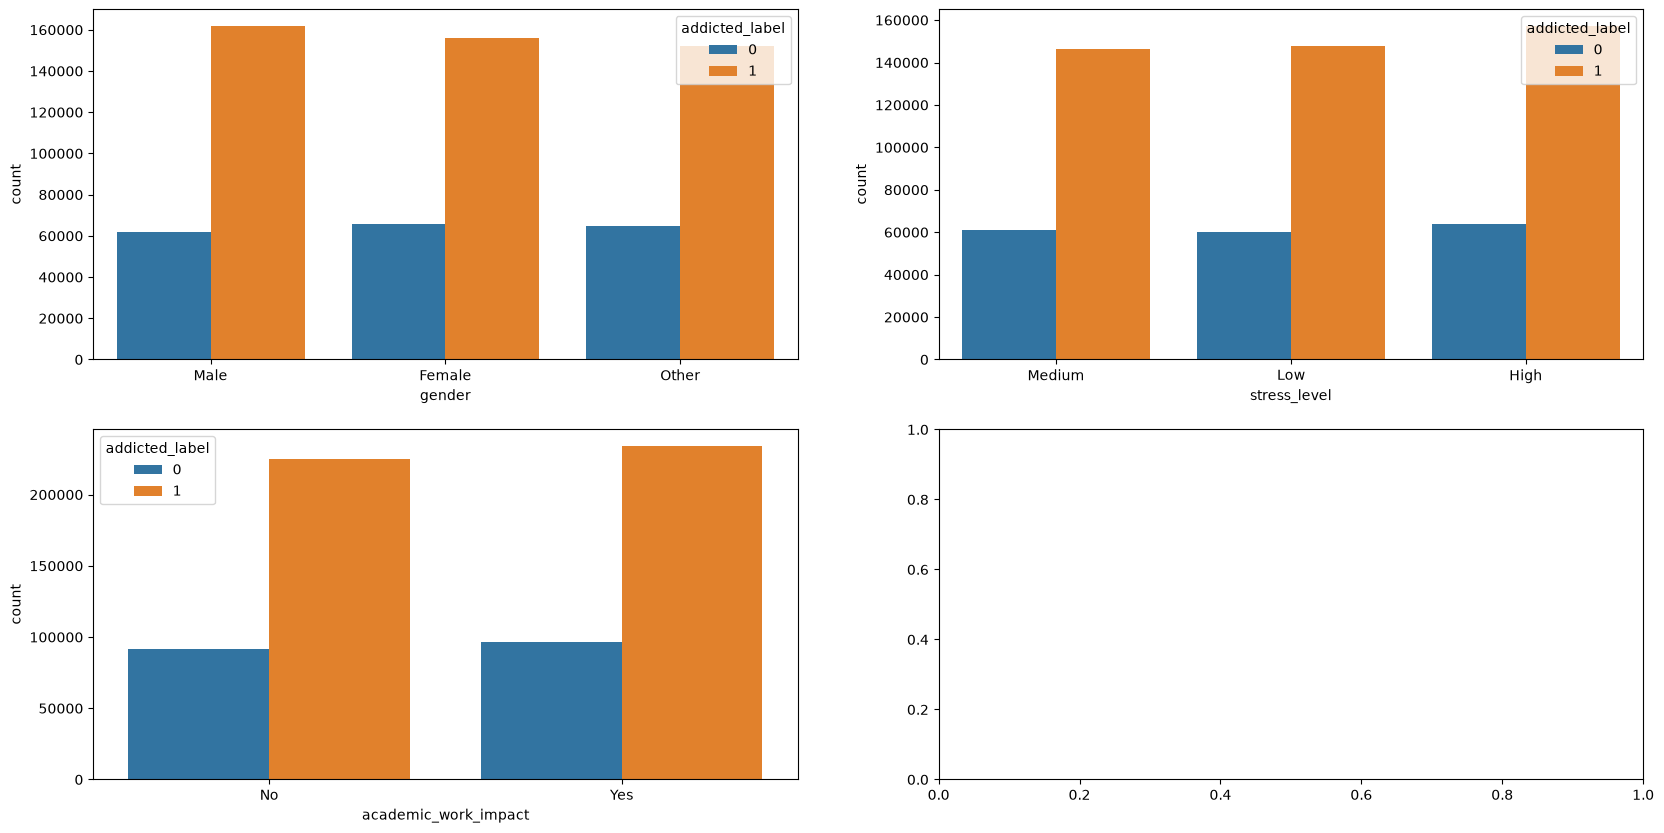

In [12]:
n_rows = (len(cat_cols)+1)//2
if n_rows > 0:
    fig,axs = plt.subplots(figsize=(20, n_rows*5), nrows=n_rows, ncols=2)

    for idx, cat_col in enumerate(cat_cols):
        sns.countplot(df, x=cat_col,hue=target_column,ax=axs[idx//2][idx%2])

Show numerical target correlations

In [13]:
num_cols = df.select_dtypes(include="float64").columns
num_cols

Index(['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
       'work_study_hours', 'sleep_hours', 'notifications_per_day',
       'app_opens_per_day', 'weekend_screen_time'],
      dtype='str')

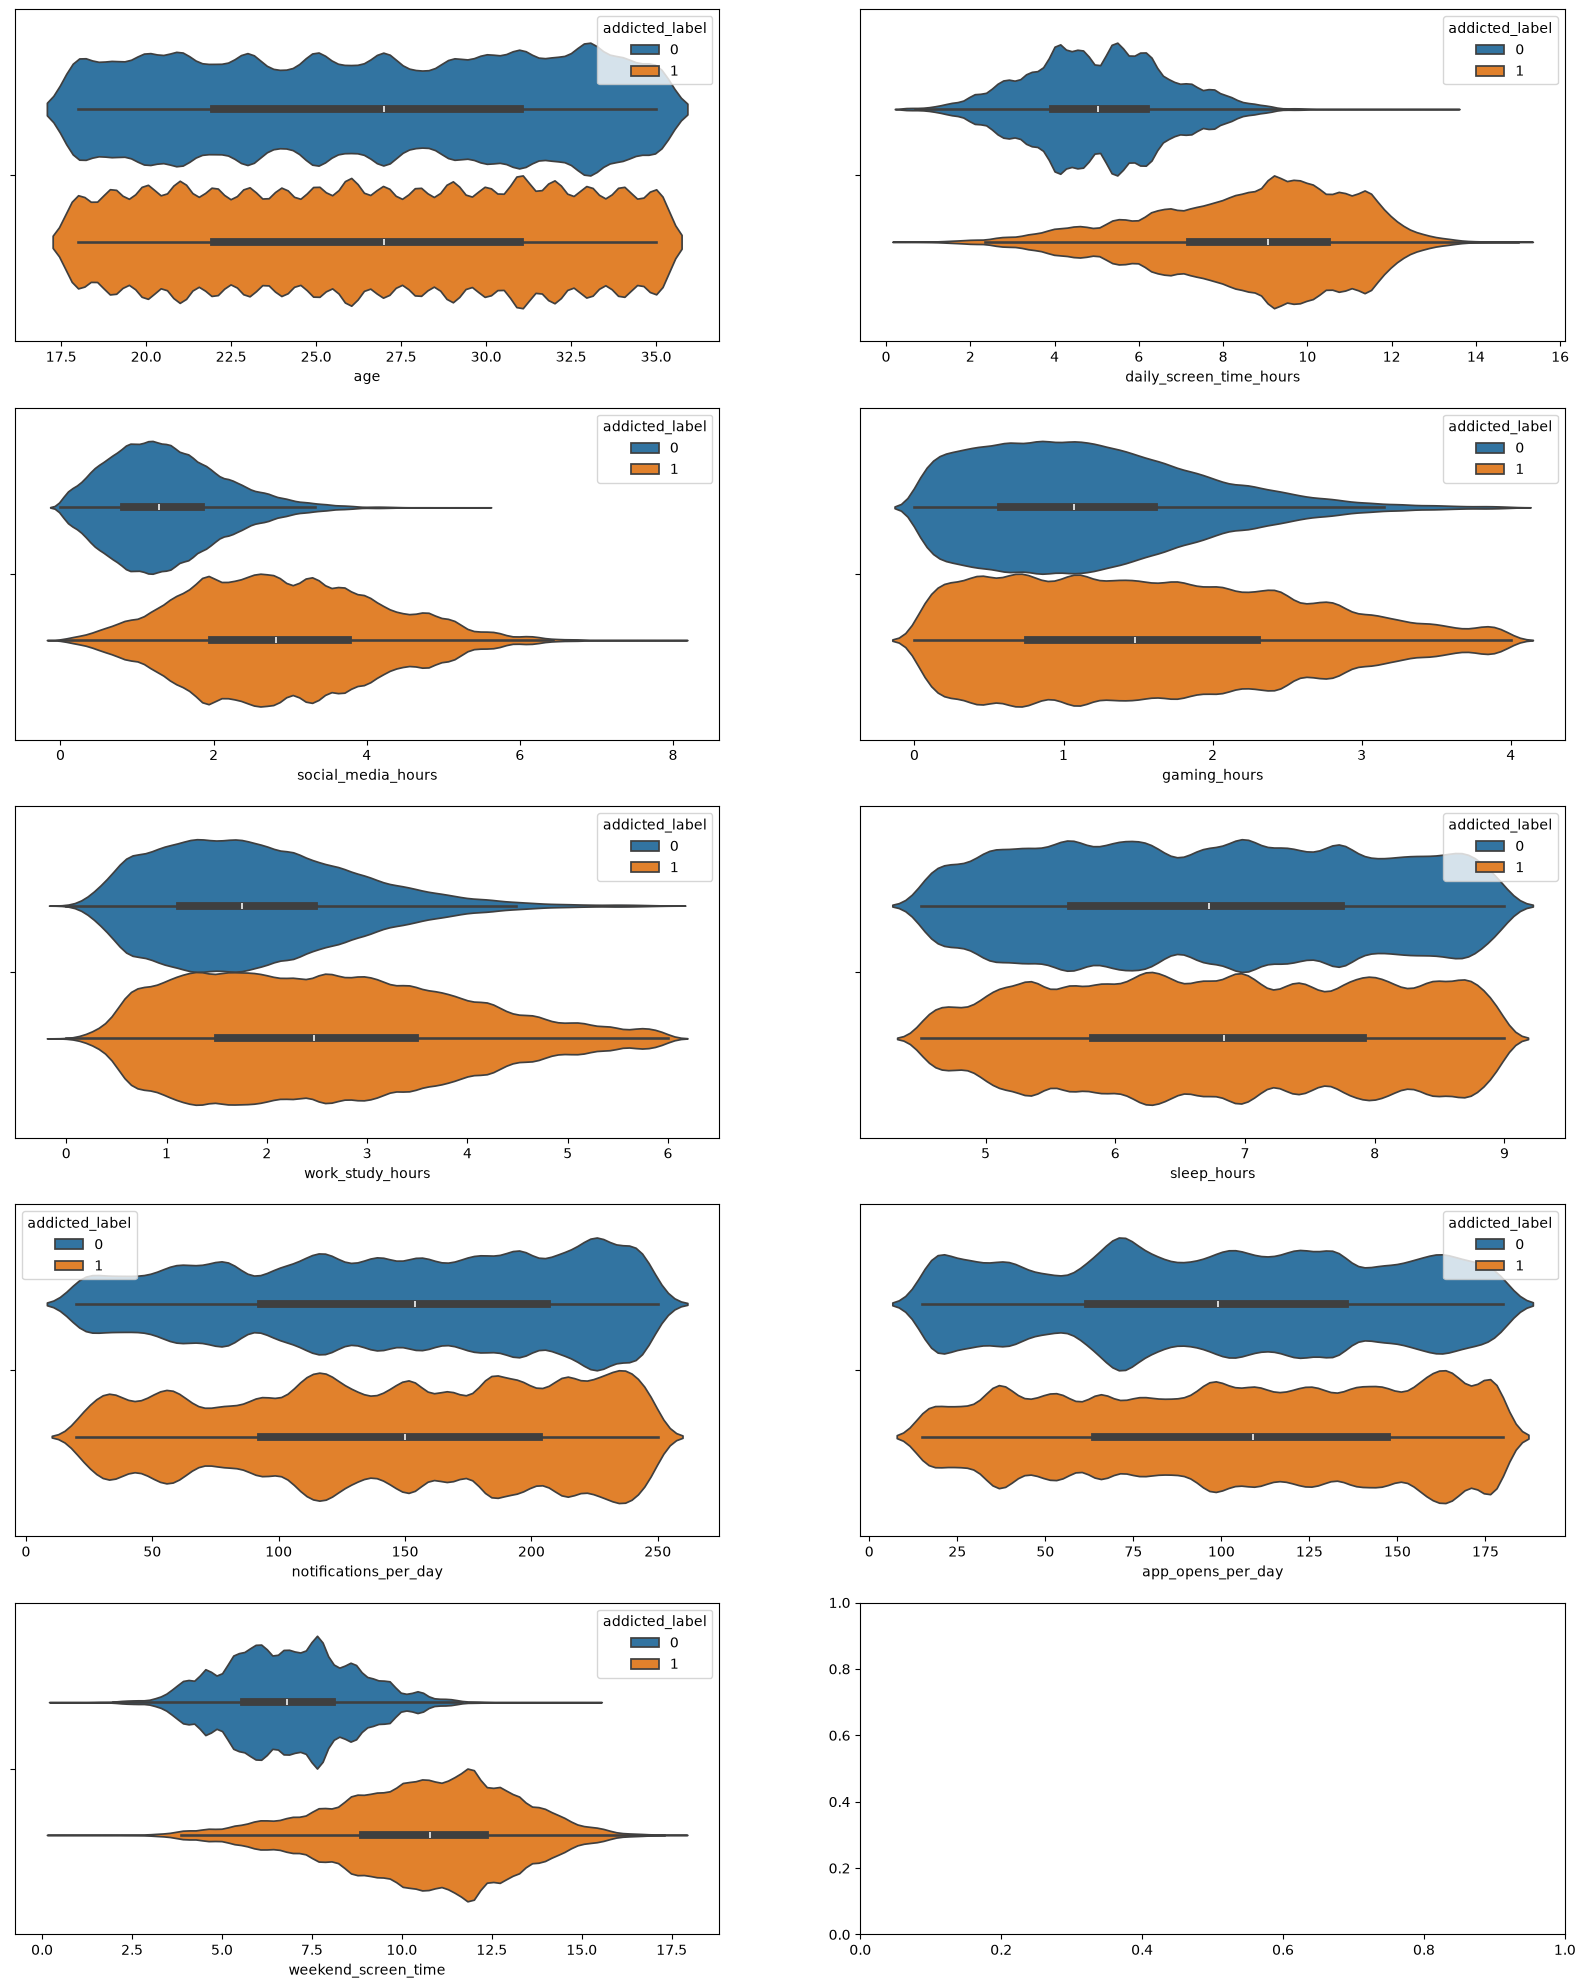

In [14]:
n_rows = (len(num_cols)+1)//2
if n_rows > 0:
    fig,axs = plt.subplots(figsize=(20, n_rows*5), nrows=n_rows, ncols=2)

    for idx, num_col in enumerate(num_cols):
        sns.violinplot(df, x=num_col,hue=target_column,ax=axs[idx//2][idx%2])

Show histograms of numerical features

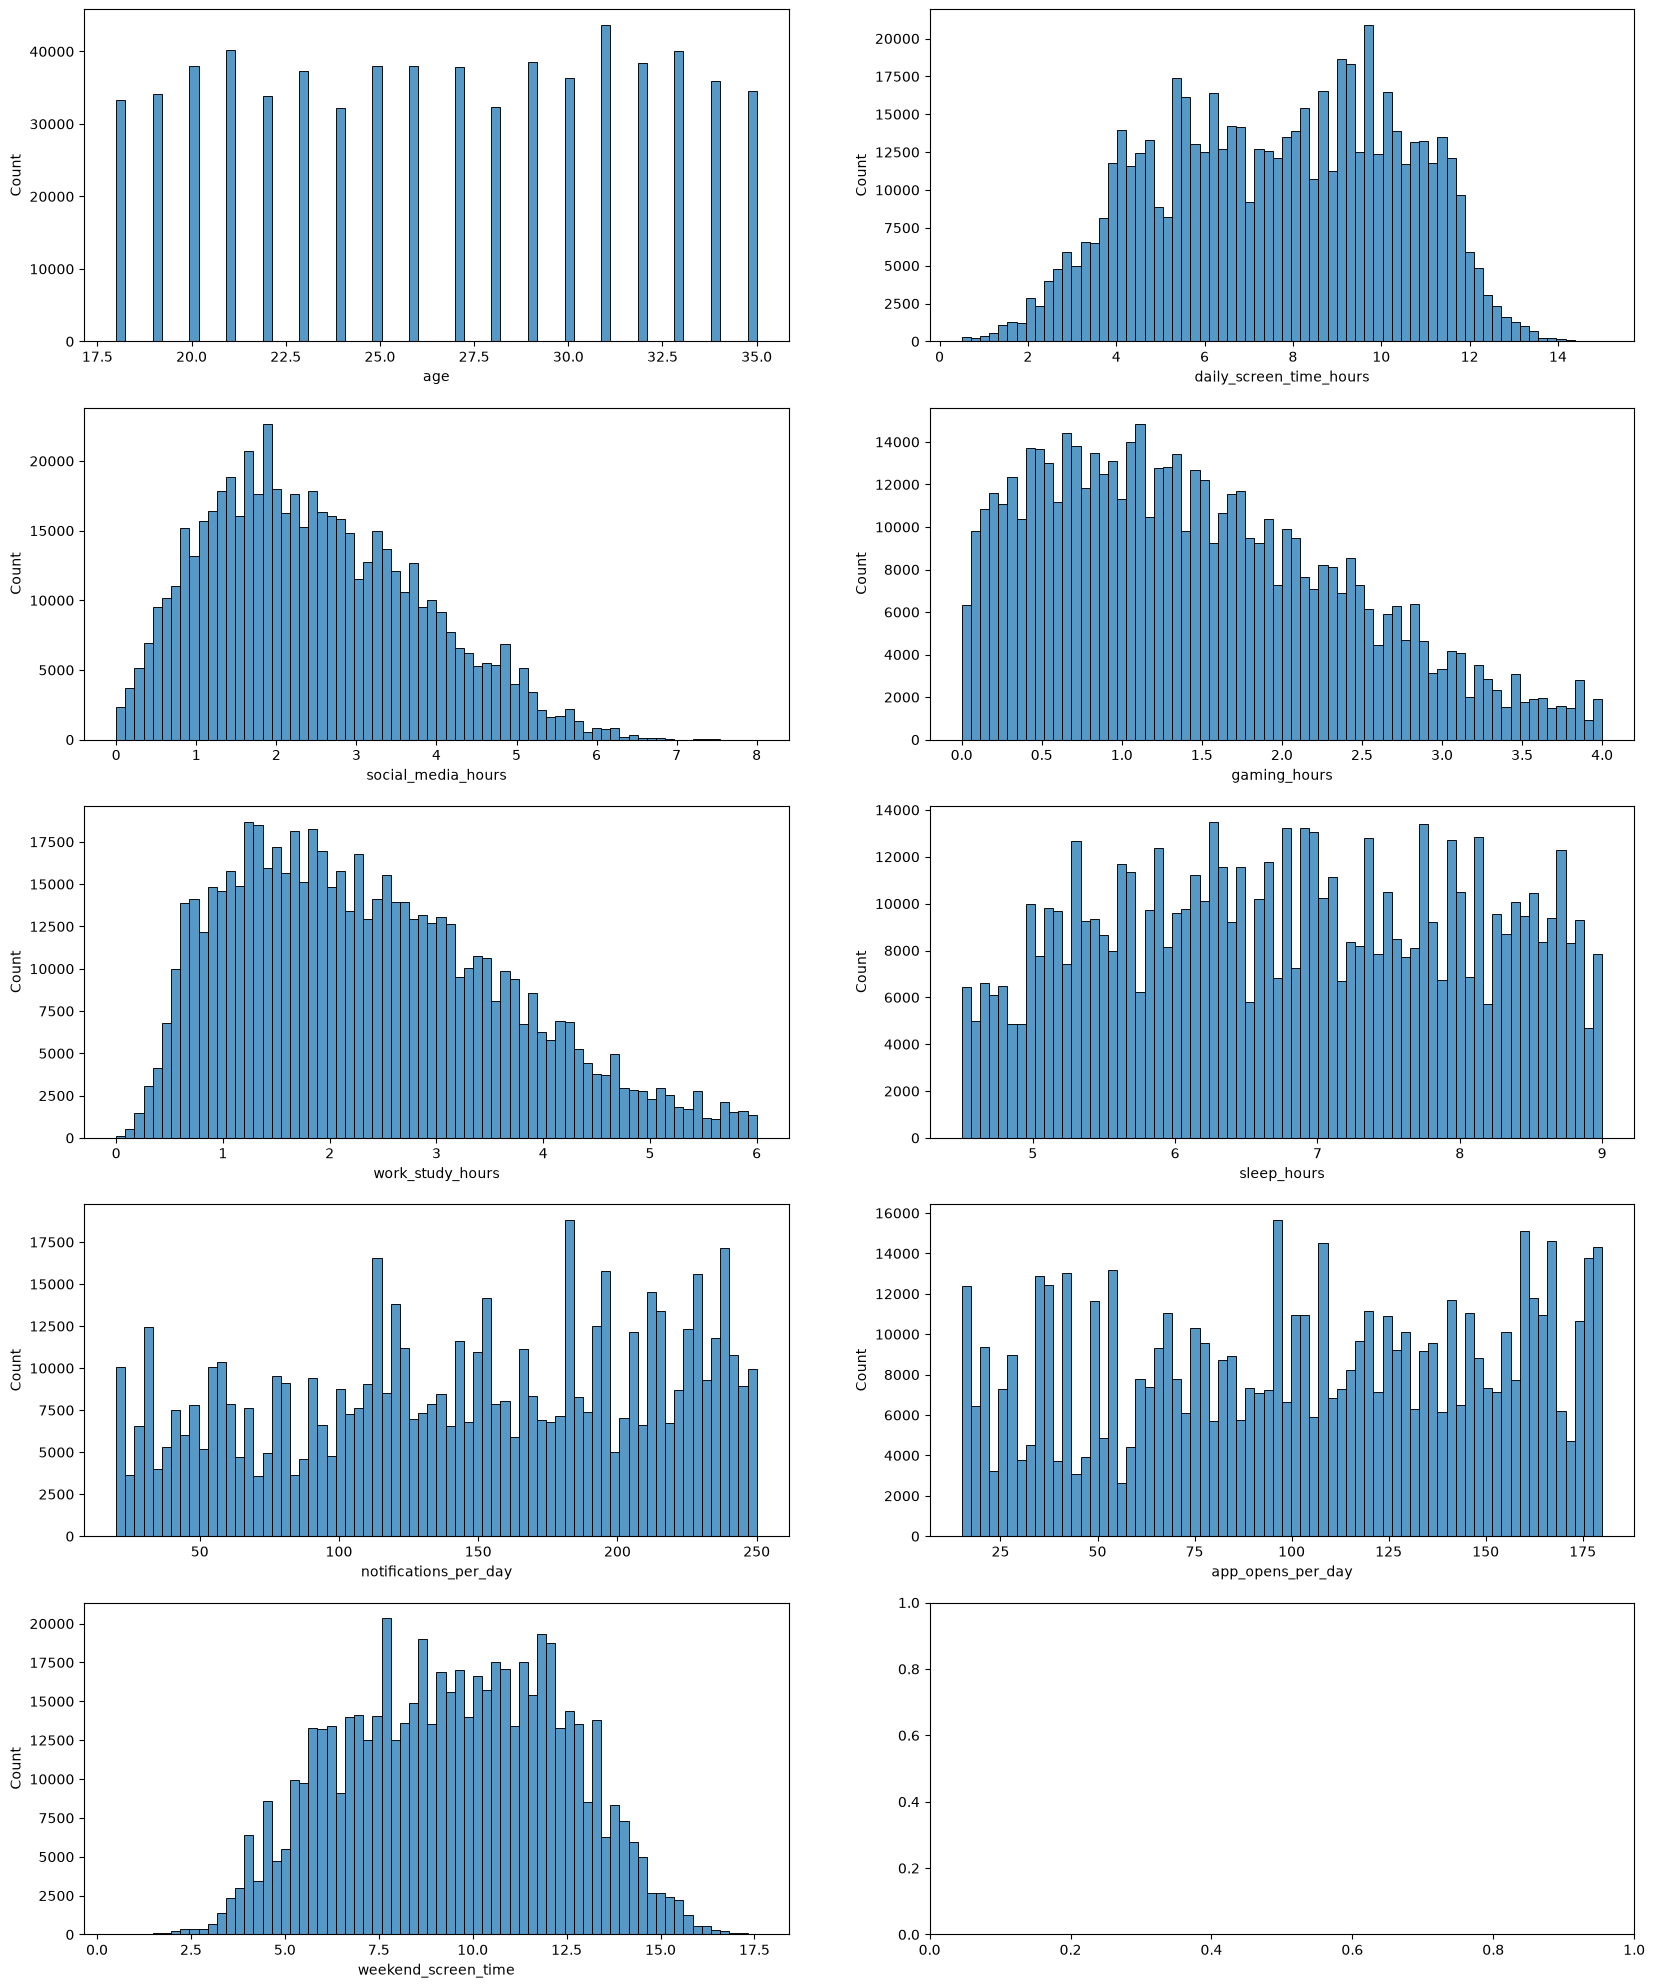

In [15]:
if n_rows > 0:
    fig,axs = plt.subplots(figsize=(20, n_rows*5), nrows=n_rows, ncols=2)

    for idx, num_col in enumerate(num_cols):
        sns.histplot(df, x=num_col,ax=axs[idx//2][idx%2],bins=70)

**Check patterns across non-target numerical features**

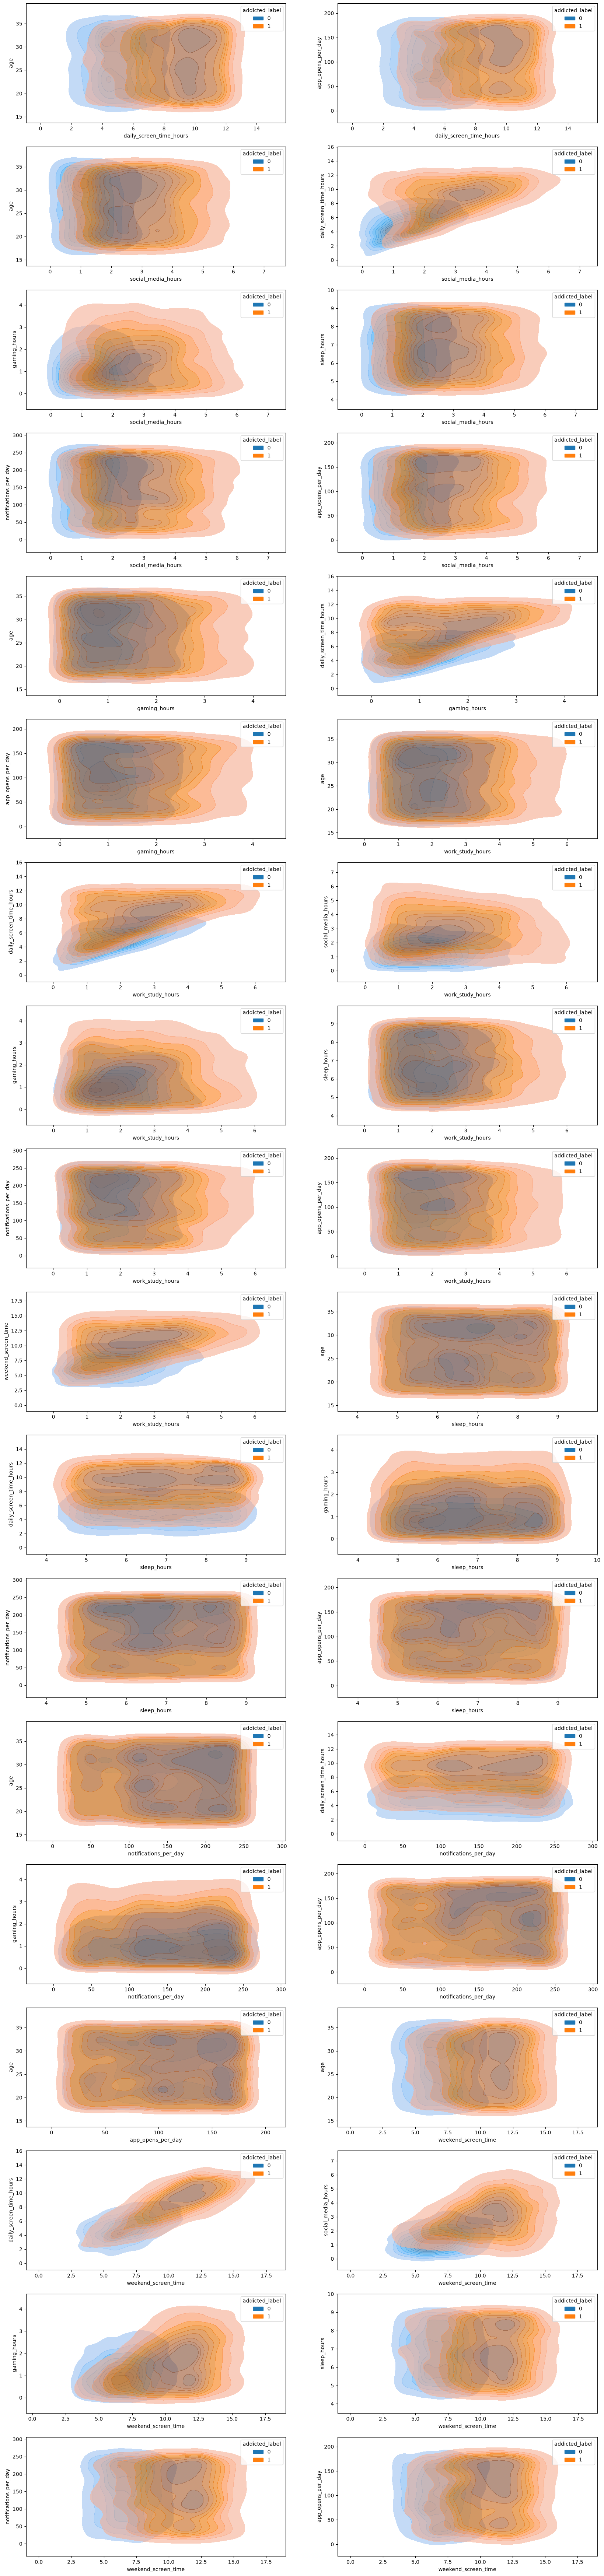

In [16]:
ddf = df.sample(n=10000, random_state=42) # Sample 10000 rows

n_rows = ((len(num_cols)*(len(num_cols)-1))//2+1)//2
if n_rows > 0:
    fig,axs = plt.subplots(figsize=(20, n_rows*5), nrows=n_rows, ncols=2)

    i = 0

    for r, c1 in enumerate(num_cols):
        for c, c2 in enumerate(num_cols):
            if c2 >= c1:
                continue
            sns.kdeplot(ddf, x=c1, y=c2, hue=target_column, ax=axs[i//2][i%2], fill=True, alpha=0.6, common_norm=True)
            i += 1

**Check patterns across numerical categorical features**

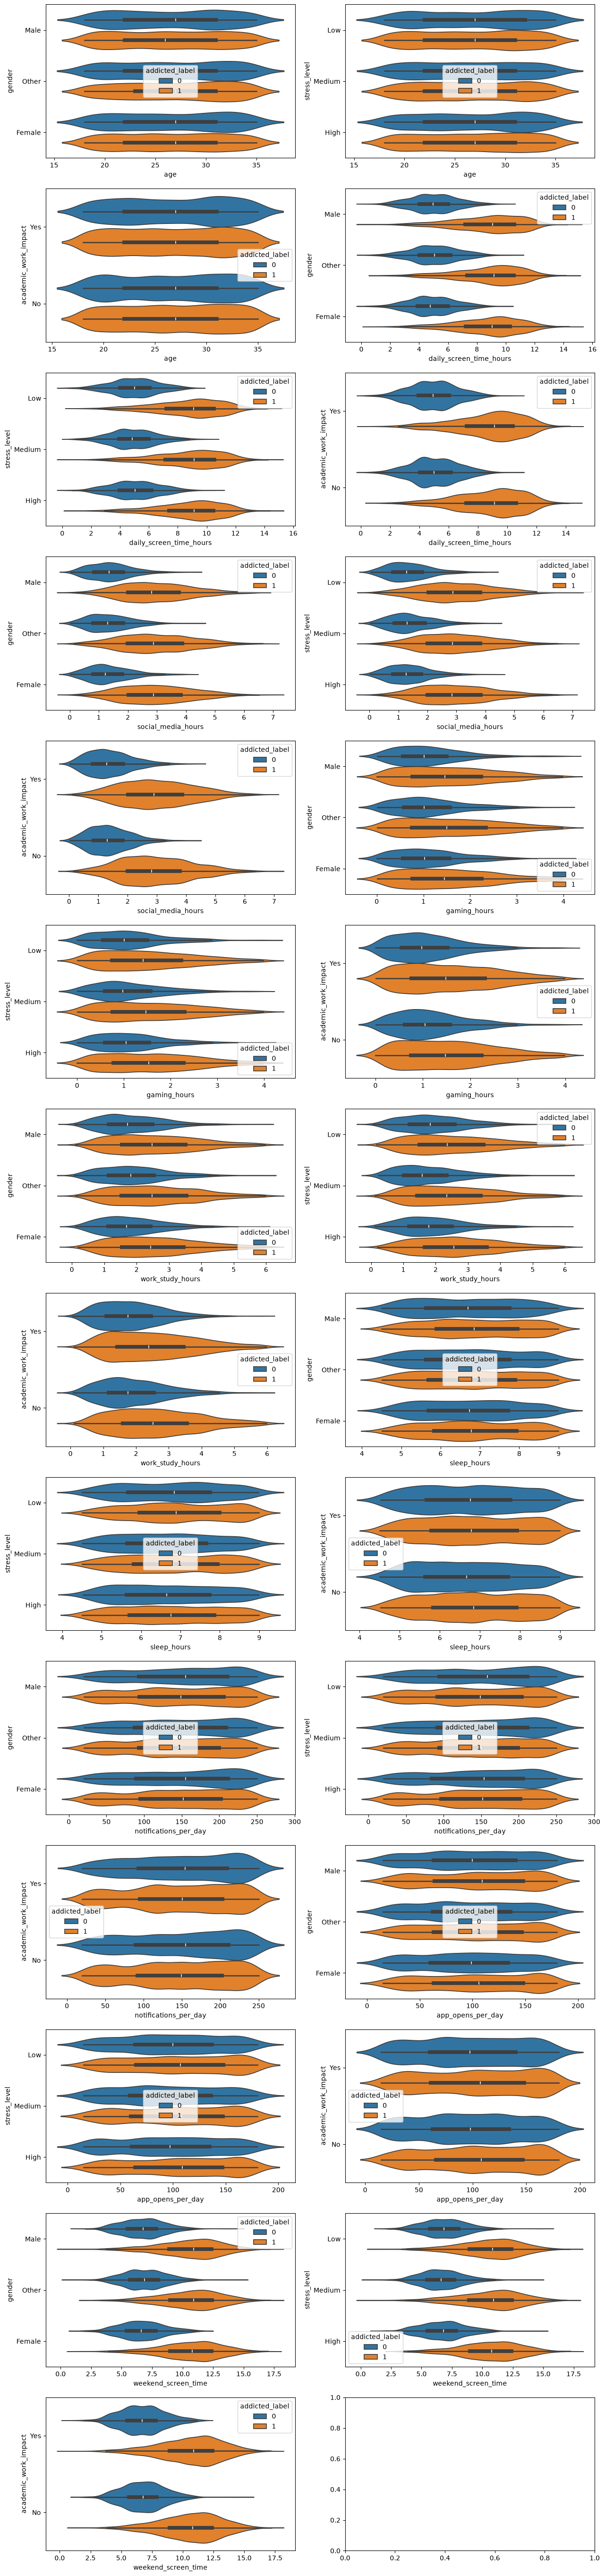

In [17]:
n_graphs = len(cat_cols) * len(num_cols)
n_rows = (n_graphs+1)//2

if n_rows > 0:
    fig, axs = plt.subplots(figsize=(15, n_rows*5),nrows=n_rows, ncols=2)

    i = 0

    for r, num_col in enumerate(num_cols):
        for c, cat_col in enumerate(cat_cols):
            sns.violinplot(ddf, x=num_col, y=cat_col, hue=target_column, ax=axs[i//2][i%2])
            i += 1

**Check patterns across cross categorical features**

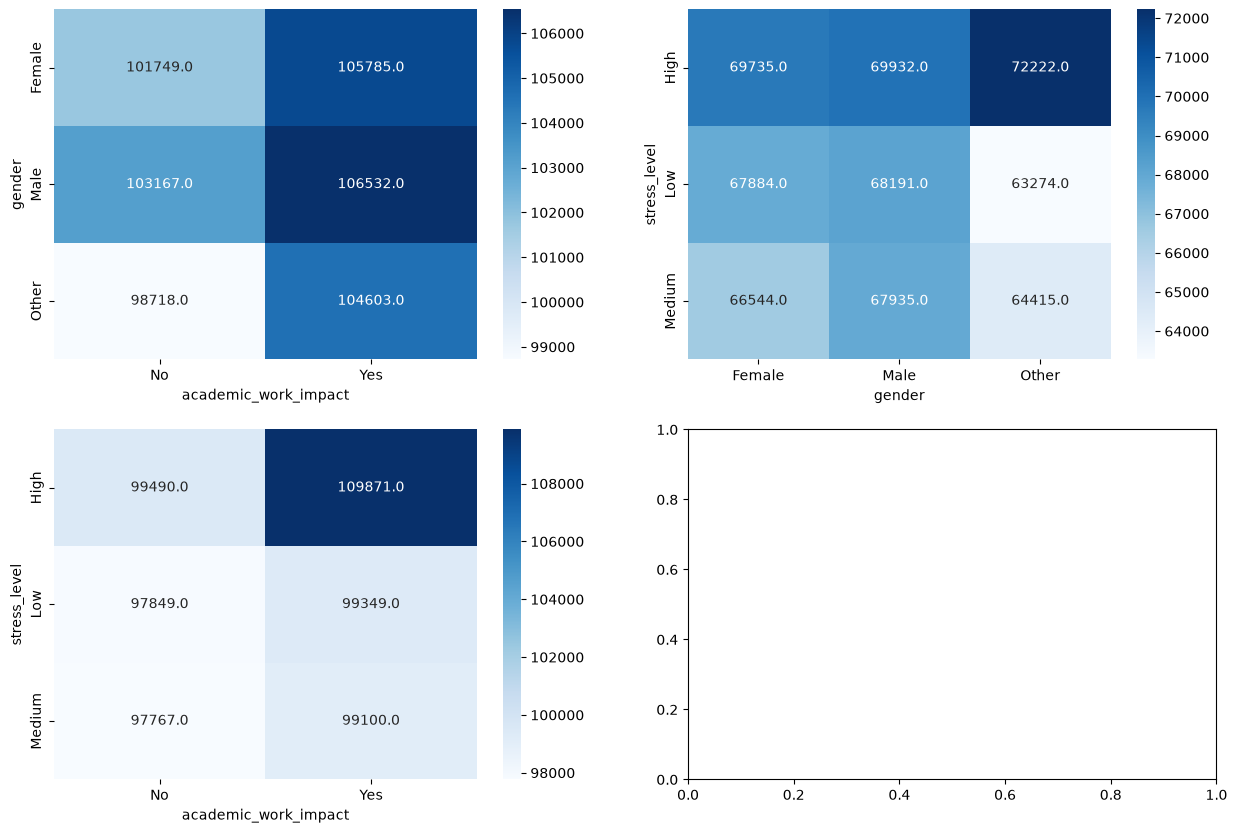

In [18]:
n_graphs = len(cat_cols) * (len(cat_cols)-1) // 2
n_rows = (n_graphs+1)//2

if n_rows > 0:
    fig, axs = plt.subplots(figsize=(15, n_rows*5),nrows=n_rows, ncols=2)

    cmap = sns.color_palette("Blues", as_cmap=True)

    i = 0

    for r, c1 in enumerate(cat_cols):
        for c, c2 in enumerate(cat_cols):
            if c2 >= c1:
                continue
            sns.heatmap(pd.crosstab(df[c1], df[c2]), annot=True, fmt=".1f",ax=axs[i//2][i%2],cmap=cmap)
            i += 1

**Spearman Correlation Matrix (Numerical features)**

<Axes: >

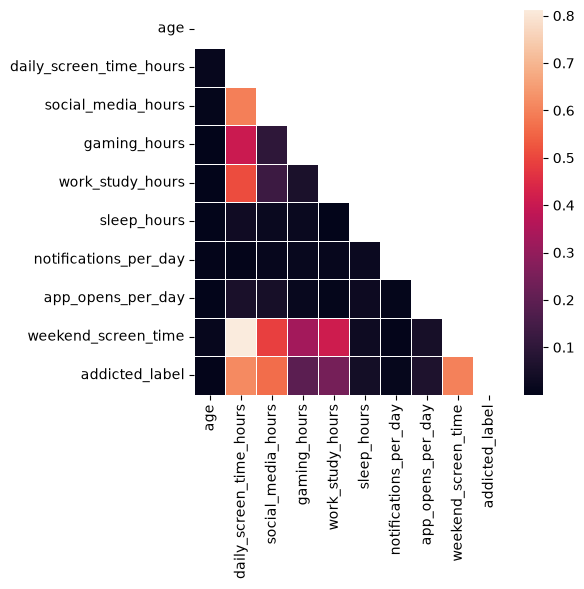

In [7]:
data_corr = df.copy()
data_corr.drop(['id'], axis=1, inplace=True)
data_corr.drop(cat_cols, axis=1, inplace=True)

corr = data_corr.corr(method='spearman').abs()
matrix_mask = np.triu(np.ones_like(corr)) # only show the lower triangular

f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(corr, linewidths=.5, mask=matrix_mask)

**Mutual information (Categorical features)**

C:\Users\abhin\AppData\Local\Temp\ipykernel_10260\3982025757.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mutual_info_values, y=no_nan.columns.values, palette="viridis")


Text(0.5, 1.0, 'Mutual Information vs. Target (addicted_label)')

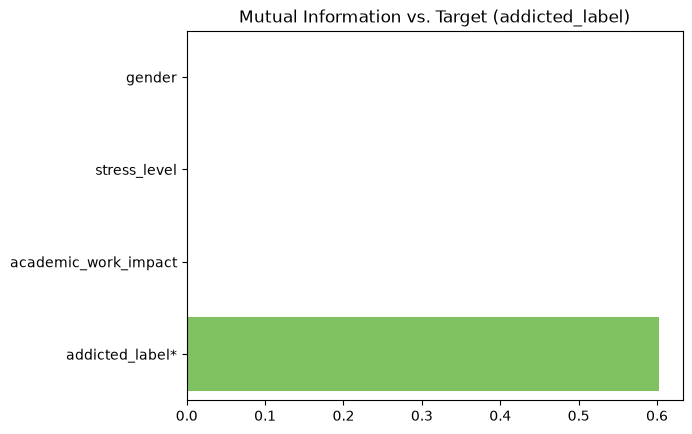

In [20]:
from sklearn.feature_selection import mutual_info_classif

data_corr = df.copy()
data_corr.drop(['id'], axis=1, inplace=True)
data_corr.drop(num_cols, axis=1, inplace=True)

corr_no_nan = data_corr.dropna()

corr_no_nan['gender'] = corr_no_nan['gender'].replace({'Other':0, 'Female':1, 'Male':2})
corr_no_nan['stress_level'] = corr_no_nan['stress_level'].replace({'Low':0, 'Medium':1, 'High':2})
corr_no_nan['academic_work_impact'] = corr_no_nan['academic_work_impact'].replace({'No':0, 'Yes':1})

corr_no_nan[f'{target_column}*'] = corr_no_nan[target_column] # a base stable column for comparison with other features

y = corr_no_nan[target_column].astype('int')
no_nan = corr_no_nan.drop(target_column, axis=1)

X = no_nan
mutual_info_values = mutual_info_classif(X, y, discrete_features=True)
sns.barplot(x=mutual_info_values, y=no_nan.columns.values, palette="viridis")
plt.title(f"Mutual Information vs. Target ({target_column})")

**Cramers' V (Categorical Features)**

In [21]:
data_corr = df.copy()
data_corr.drop(['id'], axis=1, inplace=True)
data_corr.drop(num_cols, axis=1, inplace=True)

corr_no_nan = data_corr.dropna()

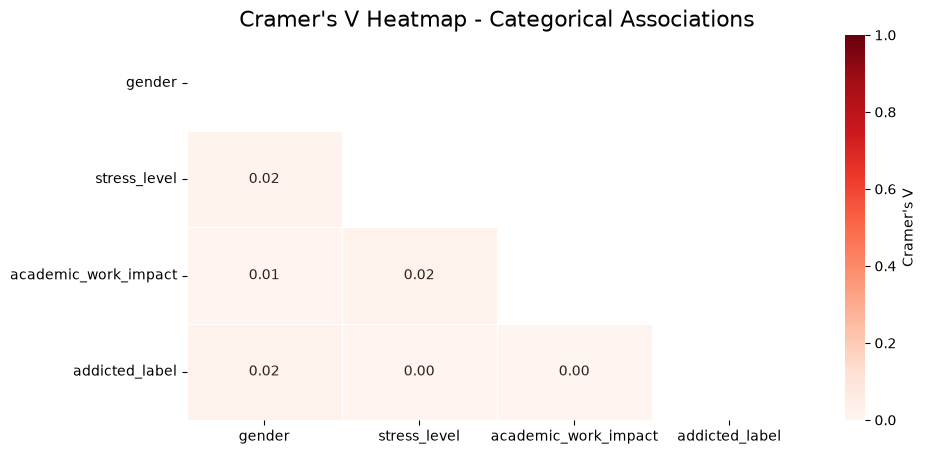

In [24]:
def cramers_corrected_stat(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum()
    phi2 = chi2/n
    r,k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))    
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min( (kcorr-1), (rcorr-1)))

def cramers_heatmap(df):
    cols = df.columns.values
    n_cols = len(cols)
    v_matrix = np.zeros((n_cols, n_cols))

    for i in range(n_cols):
        for j in range(i+1, n_cols):
            crosstab = pd.crosstab(df[cols[i]], df[cols[j]]).to_numpy()
            v = cramers_corrected_stat(crosstab)
            v_matrix[i, j] = v
            v_matrix[j, i] = v

    v_df = pd.DataFrame(v_matrix, index=cols, columns=cols)

    # mask the upper triangle
    mask = np.triu(np.ones_like(v_df, dtype=bool))

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.heatmap(
        v_df,
        linewidths=0.5,
        mask=mask,
        annot=True,
        fmt='.2f',
        vmin=0,
        vmax=1,
        cmap='Reds',
        cbar_kws={'label': "Cramer's V"}
    )
    plt.title("Cramer's V Heatmap - Categorical Associations", fontsize=16)
    plt.show()

cramers_heatmap(corr_no_nan)